# **MACHINE LEARNING**
## **Regresión Lineal — Datos Sociodemográficos y Recursos de Salud (EE.UU. 2018-2019)**

### Estructura del Notebook


 1. Carga del conjunto de datos
 2. Análisis Exploratorio de Datos (EDA)
 3. Modelo de Regresión Lineal (Baseline) + Lasso
 4. Optimización del Modelo Lasso

## **1. Carga del Conjunto de Datos**

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [123]:
# Carga del dataset
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv')

df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


Este dataset vemos como se analiza parte de la población de Estados Unidos, se dividen por edades, etnia y origen, estudios, por estado de residencia, y sus posibles enfermedades.

Voy a aplicar un diccionario para traducir las 108 columnas para ser más consciente con que datos estoy trabajando realmente y agruparlas por categorías para saber a que hace referencia cada categoría realmente.

In [124]:
# DICCIONARIO DE TRADUCCIÓN — 108 columnas organizadas por categoría

traduccion = {

    # --- IDENTIFICADORES GEOGRÁFICOS ---
    'fips'                    : 'codigo_fips',
    'COUNTY_NAME'             : 'nombre_condado',
    'STATE_NAME'              : 'nombre_estado',
    'STATE_FIPS'              : 'codigo_fips_estado',
    'CNTY_FIPS'               : 'codigo_fips_condado',

    # --- POBLACIÓN TOTAL Y ESTIMACIONES ---
    'TOT_POP'                 : 'poblacion_total',
    'Total Population'        : 'poblacion_total_alt',
    'POP_ESTIMATE_2018'       : 'estimacion_poblacion_2018',
    'N_POP_CHG_2018'          : 'cambio_poblacion_2018',
    'GQ_ESTIMATES_2018'       : 'estimacion_viviendas_colectivas_2018',

    # --- GRUPOS DE EDAD ---
    '0-9'                                   : 'pob_0_9',
    '0-9 y/o % of total pop'                : 'pct_0_9',
    '19-Oct'                                : 'pob_10_19',      # Error corregido
    '10-19 y/o % of total pop'              : 'pct_10_19',
    '20-29'                                 : 'pob_20_29',
    '20-29 y/o % of total pop'              : 'pct_20_29',
    '30-39'                                 : 'pob_30_39',
    '30-39 y/o % of total pop'              : 'pct_30_39',
    '40-49'                                 : 'pob_40_49',
    '40-49 y/o % of total pop'              : 'pct_40_49',
    '50-59'                                 : 'pob_50_59',
    '50-59 y/o % of total pop'              : 'pct_50_59',
    '60-69'                                 : 'pob_60_69',
    '60-69 y/o % of total pop'              : 'pct_60_69',
    '70-79'                                 : 'pob_70_79',
    '70-79 y/o % of total pop'              : 'pct_70_79',
    '80+'                                   : 'pob_80_mas',
    '80+ y/o % of total pop'                : 'pct_80_mas',
    'Population Aged 60+'                   : 'pob_60_mas',
    'Percent of Population Aged 60+'        : 'pct_60_mas',
    'county_pop2018_18 and older'           : 'pob_18_mas_2018',

    # --- RAZA / ETNIA ---
    'White-alone pop'                              : 'pob_blanca',
    '% White-alone'                                : 'pct_blanca',
    'Black-alone pop'                              : 'pob_negra',
    '% Black-alone'                                : 'pct_negra',
    'Native American/American Indian-alone pop'    : 'pob_nativa_americana',
    '% NA/AI-alone'                                : 'pct_nativa_americana',
    'Asian-alone pop'                              : 'pob_asiatica',
    '% Asian-alone'                                : 'pct_asiatica',
    'Hawaiian/Pacific Islander-alone pop'          : 'pob_hawaiana_pacifico',
    '% Hawaiian/PI-alone'                          : 'pct_hawaiana_pacifico',
    'Two or more races pop'                        : 'pob_multirracial',
    '% Two or more races'                          : 'pct_multirracial',

    # --- TASAS DEMOGRÁFICAS VITALES ---
    'R_birth_2018'               : 'tasa_natalidad_2018',
    'R_death_2018'               : 'tasa_mortalidad_2018',
    'R_NATURAL_INC_2018'         : 'tasa_crecimiento_natural_2018',
    'R_INTERNATIONAL_MIG_2018'   : 'tasa_migracion_internacional_2018',
    'R_DOMESTIC_MIG_2018'        : 'tasa_migracion_nacional_2018',
    'R_NET_MIG_2018'             : 'tasa_migracion_neta_2018',

    # --- EDUCACIÓN ---
    'Less than a high school diploma 2014-18'                          : 'n_sin_bachillerato',
    'High school diploma only 2014-18'                                 : 'n_solo_bachillerato',
    "Some college or associate's degree 2014-18"                       : 'n_universitario_parcial',
    "Bachelor's degree or higher 2014-18"                              : 'n_universitario_completo',
    'Percent of adults with less than a high school diploma 2014-18'   : 'pct_sin_bachillerato',
    'Percent of adults with a high school diploma only 2014-18'        : 'pct_solo_bachillerato',
    "Percent of adults completing some college or associate's degree 2014-18" : 'pct_universitario_parcial',
    "Percent of adults with a bachelor's degree or higher 2014-18"     : 'pct_universitario_completo',

    # --- POBREZA E INGRESOS ---
    'POVALL_2018'                              : 'n_personas_en_pobreza',
    'PCTPOVALL_2018'                           : 'pct_pobreza',
    'PCTPOV017_2018'                           : 'pct_pobreza_menores_18',
    'PCTPOV517_2018'                           : 'pct_pobreza_5_17',
    'MEDHHINC_2018'                            : 'ingreso_mediano_familiar',
    'CI90LBINC_2018'                           : 'ingreso_ic90_inferior',
    'CI90UBINC_2018'                           : 'ingreso_ic90_superior',
    'Median_Household_Income_2018'             : 'ingreso_mediano_familiar_alt',
    'Med_HH_Income_Percent_of_State_Total_2018': 'ingreso_mediano_pct_estatal',

    # --- EMPLEO ---
    'Civilian_labor_force_2018' : 'fuerza_laboral_civil',
    'Employed_2018'             : 'n_empleados',
    'Unemployed_2018'           : 'n_desempleados',
    'Unemployment_rate_2018'    : 'tasa_desempleo',

    # --- RECURSOS SANITARIOS: PERSONAL MÉDICO ---
    'Active Physicians per 100000 Population 2018 (AAMC)'                          : 'medicos_activos_por_100k',
    'Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)'       : 'medicos_atencion_paciente_por_100k',
    'Active Primary Care Physicians per 100000 Population 2018 (AAMC)'             : 'medicos_atencion_primaria_por_100k',
    'Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)': 'medicos_primaria_ejercicio_por_100k',
    'Active General Surgeons per 100000 Population 2018 (AAMC)'                    : 'cirujanos_generales_por_100k',
    'Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)'       : 'cirujanos_ejercicio_por_100k',
    'Total nurse practitioners (2019)'                                              : 'enfermeros_especializados',
    'Total physician assistants (2019)'                                             : 'auxiliares_medicos',

    # --- RECURSOS SANITARIOS: INFRAESTRUCTURA ---
    'Total Hospitals (2019)'                              : 'total_hospitales',
    'Internal Medicine Primary Care (2019)'               : 'medicos_medicina_interna',
    'Family Medicine/General Practice Primary Care (2019)': 'medicos_medicina_familiar',
    'Total Specialist Physicians (2019)'                  : 'total_especialistas',
    'ICU Beds_x'                                          : 'camas_uci',

    # --- ENFERMEDADES CRÓNICAS: CUALQUIER CONDICIÓN ---
    'anycondition_prevalence'      : 'prevalencia_cualquier_condicion',
    'anycondition_Lower 95% CI'    : 'cualquier_condicion_ic95_inferior',
    'anycondition_Upper 95% CI'    : 'cualquier_condicion_ic95_superior',
    'anycondition_number'          : 'n_cualquier_condicion',

    # --- ENFERMEDADES CRÓNICAS: OBESIDAD ---
    'Obesity_prevalence'           : 'prevalencia_obesidad',
    'Obesity_Lower 95% CI'         : 'obesidad_ic95_inferior',
    'Obesity_Upper 95% CI'         : 'obesidad_ic95_superior',
    'Obesity_number'               : 'n_obesidad',

    # --- ENFERMEDADES CRÓNICAS: CARDIOPATÍA ---
    'Heart disease_prevalence'     : 'prevalencia_cardiopatia',
    'Heart disease_Lower 95% CI'   : 'cardiopatia_ic95_inferior',
    'Heart disease_Upper 95% CI'   : 'cardiopatia_ic95_superior',
    'Heart disease_number'         : 'n_cardiopatia',

    # --- ENFERMEDADES CRÓNICAS: EPOC ---
    'COPD_prevalence'              : 'prevalencia_epoc',
    'COPD_Lower 95% CI'            : 'epoc_ic95_inferior',
    'COPD_Upper 95% CI'            : 'epoc_ic95_superior',
    'COPD_number'                  : 'n_epoc',

    # --- ENFERMEDADES CRÓNICAS: DIABETES ---
    'diabetes_prevalence'          : 'prevalencia_diabetes',
    'diabetes_Lower 95% CI'        : 'diabetes_ic95_inferior',
    'diabetes_Upper 95% CI'        : 'diabetes_ic95_superior',
    'diabetes_number'              : 'n_diabetes',

    # --- ENFERMEDADES CRÓNICAS: ENFERMEDAD RENAL CRÓNICA (ERC) ---
    'CKD_prevalence'               : 'prevalencia_erc',
    'CKD_Lower 95% CI'             : 'erc_ic95_inferior',
    'CKD_Upper 95% CI'             : 'erc_ic95_superior',
    'CKD_number'                   : 'n_erc',

    # --- CLASIFICACIÓN TERRITORIAL ---
    'Urban_rural_code'             : 'codigo_urbano_rural',
}

# APLICAMOS LA TRADUCCIÓN
df.rename(columns=traduccion, inplace=True)

print(f'✔ Columnas renombradas: {len(traduccion)}')
print(f'Shape: {df.shape}')
df.head()

✔ Columnas renombradas: 108
Shape: (3140, 108)


,codigo_fips,poblacion_total,pob_0_9,pct_0_9,pob_10_19,pct_10_19,pob_20_29,pct_20_29,pob_30_39,pct_30_39,...,n_epoc,prevalencia_diabetes,diabetes_ic95_inferior,diabetes_ic95_superior,n_diabetes,prevalencia_erc,erc_ic95_inferior,erc_ic95_superior,n_erc,codigo_urbano_rural
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


### **1.2 Definición de categorías de variables**

Organizamos las columnas en grupos para poder analizarlas y usarlas de forma estructurada.

In [125]:
# CATEGORÍAS DE VARIABLES

# IDENTIFICADORES — no entran al modelo
vars_ids = [
    'codigo_fips', 'nombre_condado', 'nombre_estado',
    'codigo_fips_estado', 'codigo_fips_condado'
]

# POBLACIÓN Y ESTIMACIONES
vars_poblacion = [
    'poblacion_total', 'poblacion_total_alt', 'estimacion_poblacion_2018',
    'cambio_poblacion_2018', 'estimacion_viviendas_colectivas_2018'
]

# GRUPOS DE EDAD
vars_edad = [
    'pct_0_9', 'pct_10_19', 'pct_20_29', 'pct_30_39', 'pct_40_49',
    'pct_50_59', 'pct_60_69', 'pct_70_79', 'pct_80_mas',
    'pct_60_mas', 'pob_18_mas_2018'
]

# RAZA / ETNIA
vars_raza = [
    'pct_blanca', 'pct_negra', 'pct_nativa_americana',
    'pct_asiatica', 'pct_hawaiana_pacifico', 'pct_multirracial'
]

# TASAS VITALES
vars_vitales = [
    'tasa_natalidad_2018', 'tasa_mortalidad_2018',
    'tasa_crecimiento_natural_2018', 'tasa_migracion_internacional_2018',
    'tasa_migracion_nacional_2018', 'tasa_migracion_neta_2018'
]

# EDUCACIÓN
vars_educacion = [
    'pct_sin_bachillerato', 'pct_solo_bachillerato',
    'pct_universitario_parcial', 'pct_universitario_completo'
]

# POBREZA E INGRESOS
vars_economia = [
    'pct_pobreza', 'pct_pobreza_menores_18', 'pct_pobreza_5_17',
    'ingreso_mediano_familiar', 'ingreso_mediano_pct_estatal',
    'tasa_desempleo'
]

# RECURSOS SANITARIOS
vars_sanitarios = [
    'medicos_activos_por_100k', 'medicos_atencion_primaria_por_100k',
    'cirujanos_generales_por_100k', 'enfermeros_especializados',
    'auxiliares_medicos', 'total_hospitales', 'total_especialistas', 'camas_uci'
]

# ENFERMEDADES CRÓNICAS (solo prevalencias, sin intervalos de confianza)
vars_enfermedades = [
    'prevalencia_cualquier_condicion', 'prevalencia_obesidad',
    'prevalencia_cardiopatia', 'prevalencia_epoc',
    'prevalencia_diabetes', 'prevalencia_erc'
]

# VARIABLE OBJETIVO
TARGET = 'prevalencia_cardiopatia'

print('✔ Categorías definidas:')
print(f'  → Identificadores:       {len(vars_ids)} variables')
print(f'  → Población:             {len(vars_poblacion)} variables')
print(f'  → Grupos de edad:        {len(vars_edad)} variables')
print(f'  → Raza / etnia:          {len(vars_raza)} variables')
print(f'  → Tasas vitales:         {len(vars_vitales)} variables')
print(f'  → Educación:             {len(vars_educacion)} variables')
print(f'  → Economía / pobreza:    {len(vars_economia)} variables')
print(f'  → Recursos sanitarios:   {len(vars_sanitarios)} variables')
print(f'  → Enfermedades crónicas: {len(vars_enfermedades)} variables')
print(f'\n Variable objetivo: {TARGET}')

✔ Categorías definidas:
  → Identificadores:       5 variables
  → Población:             5 variables
  → Grupos de edad:        11 variables
  → Raza / etnia:          6 variables
  → Tasas vitales:         6 variables
  → Educación:             4 variables
  → Economía / pobreza:    6 variables
  → Recursos sanitarios:   8 variables
  → Enfermedades crónicas: 6 variables

 Variable objetivo: prevalencia_cardiopatia


En este código separo las categorías de variables que se me presnetan en el dataset.


In [126]:
# VERIFICAMOS LA ESTRUCTURA Y TIPOS DE DATOS
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, codigo_fips to codigo_urbano_rural
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


Podemos apreciar que este dataset sólo cuenta con tres tipos de valores `int`, `float` y `object`.

In [127]:
# SHAPE - DIMENSIONES (FILAS & COLUMNAS)
df.shape

(3140, 108)

Este dataset cuenta con un total de **3140 filas** y **108 columnas**.

In [128]:
# ESTADÍSTICA DESCRIPTIVA
df.describe()

,codigo_fips,poblacion_total,pob_0_9,pct_0_9,pob_10_19,pct_10_19,pob_20_29,pct_20_29,pob_30_39,pct_30_39,...,n_epoc,prevalencia_diabetes,diabetes_ic95_inferior,diabetes_ic95_superior,n_diabetes,prevalencia_erc,erc_ic95_inferior,erc_ic95_superior,n_erc,codigo_urbano_rural
count,3140.000000,3.140000e+03,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,...,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000
mean,30401.640764,1.041894e+05,1.274030e+04,11.871051,1.336798e+04,12.694609,1.446933e+04,12.283979,1.391649e+04,11.751535,...,5827.242357,13.073503,12.088089,14.053726,9326.577707,3.446242,3.207516,3.710478,2466.234076,4.635350
std,15150.559265,3.335834e+05,4.180730e+04,2.124081,4.228439e+04,1.815044,4.957773e+04,3.126297,4.899095e+04,1.696599,...,15720.551934,2.724351,2.622948,2.824828,29754.601185,0.568059,0.527740,0.613069,7730.422067,1.510447
min,1001.000000,8.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.100000e+01,6.092789,...,7.000000,6.100000,5.500000,6.700000,11.000000,1.800000,1.700000,1.900000,3.000000,1.000000
25%,18180.500000,1.096325e+04,1.280500e+03,10.594639,1.374500e+03,11.674504,1.263750e+03,10.496774,1.232750e+03,10.689322,...,815.000000,11.200000,10.300000,12.100000,1187.750000,3.100000,2.900000,3.300000,314.750000,3.000000
50%,29178.000000,2.580050e+04,3.057000e+03,11.802727,3.274000e+03,12.687422,3.108000e+03,11.772649,3.000500e+03,11.580861,...,1963.500000,12.800000,11.800000,13.800000,2743.000000,3.400000,3.200000,3.700000,718.000000,5.000000
75%,45081.500000,6.791300e+04,8.097000e+03,12.951840,8.822250e+03,13.659282,8.976250e+03,13.182260,8.314250e+03,12.639379,...,4727.000000,14.800000,13.700000,15.900000,6679.250000,3.800000,3.500000,4.100000,1776.250000,6.000000
max,56045.000000,1.010552e+07,1.208253e+06,25.460677,1.239139e+06,23.304372,1.557073e+06,37.570198,1.501844e+06,22.225129,...,434075.000000,25.600000,24.200000,27.000000,952335.000000,6.200000,5.800000,6.600000,237766.000000,6.000000


In [129]:
# CONTAMOS LOS VALORES NULOS POR COLUMNA
nulls     = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(1)

null_report = pd.DataFrame({'nulos': nulls, 'porcentaje_%': nulls_pct})
null_report = null_report[null_report['nulos'] > 0].sort_values('porcentaje_%', ascending=False)

print(f'Columnas con valores nulos: {len(null_report)}')
null_report

Columnas con valores nulos: 0


,nulos,porcentaje_%


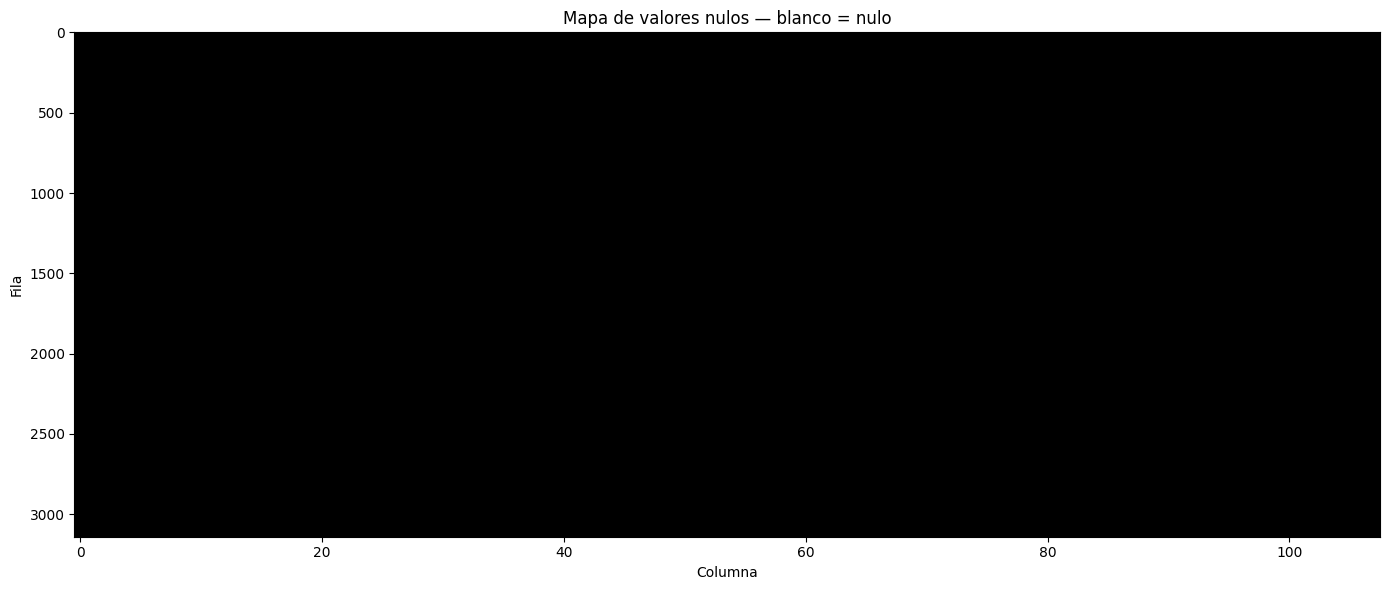

In [130]:
# MAPA VISUAL DE NULOS
plt.figure(figsize=(14, 6))
plt.imshow(df.isnull(), aspect='auto', interpolation='nearest', cmap='gray')
plt.xlabel('Columna')
plt.ylabel('Fila')
plt.title('Mapa de valores nulos — blanco = nulo')
plt.tight_layout()
plt.show()

Vemos que esta dataset tiene **0 valores nulos**.

## **2. Análisis Exploratorio de Datos (EDA)**

### **2.1 Análisis Univariante — Variable Objetivo**

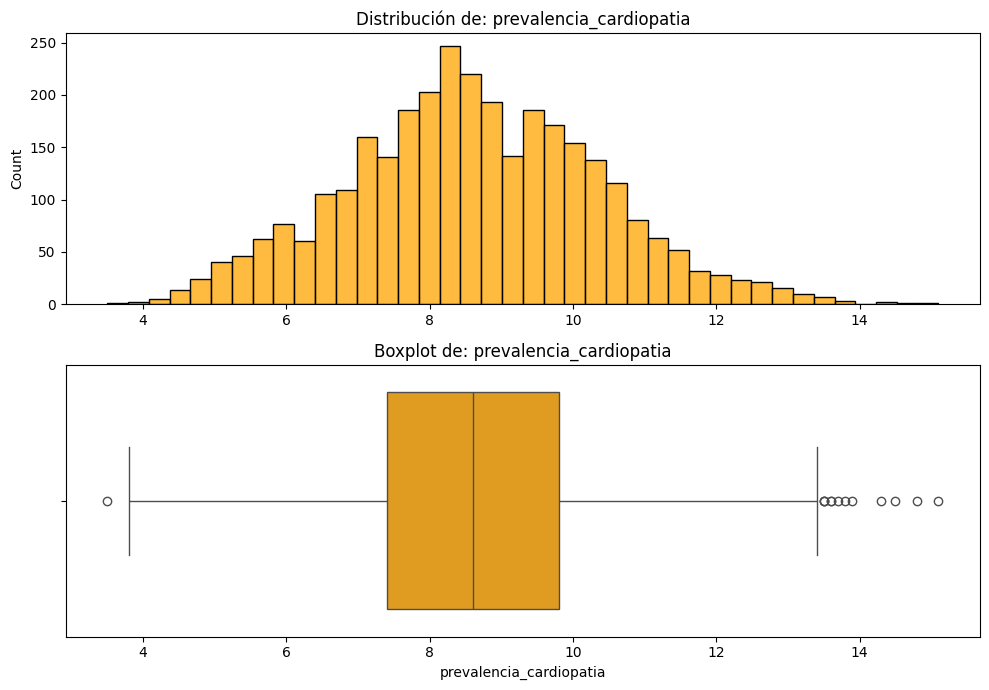

Media:            8.61%
Mediana:          8.60%
Desviación típica: 1.76%
Nulos:            0


In [131]:
fig, axis = plt.subplots(2, 1, figsize=(10, 7))

sns.histplot(ax=axis[0],
             data=df,
             x=TARGET,
             bins=40,
             color='orange')
axis[0].set_title(f'Distribución de: {TARGET}')
axis[0].set_xlabel(None)

sns.boxplot(ax=axis[1],
            data=df,
            x=TARGET,
            color='orange')
axis[1].set_title(f'Boxplot de: {TARGET}')

plt.tight_layout()
plt.show()

print(f'Media:            {df[TARGET].mean():.2f}%')
print(f'Mediana:          {df[TARGET].median():.2f}%')
print(f'Desviación típica: {df[TARGET].std():.2f}%')
print(f'Nulos:            {df[TARGET].isnull().sum()}')

### **2.2 Análisis Univariante — Variables por Categoría**

Gracias a que tenemos las variables organizadas por categorías, podemos explorarlas grupo a grupo.

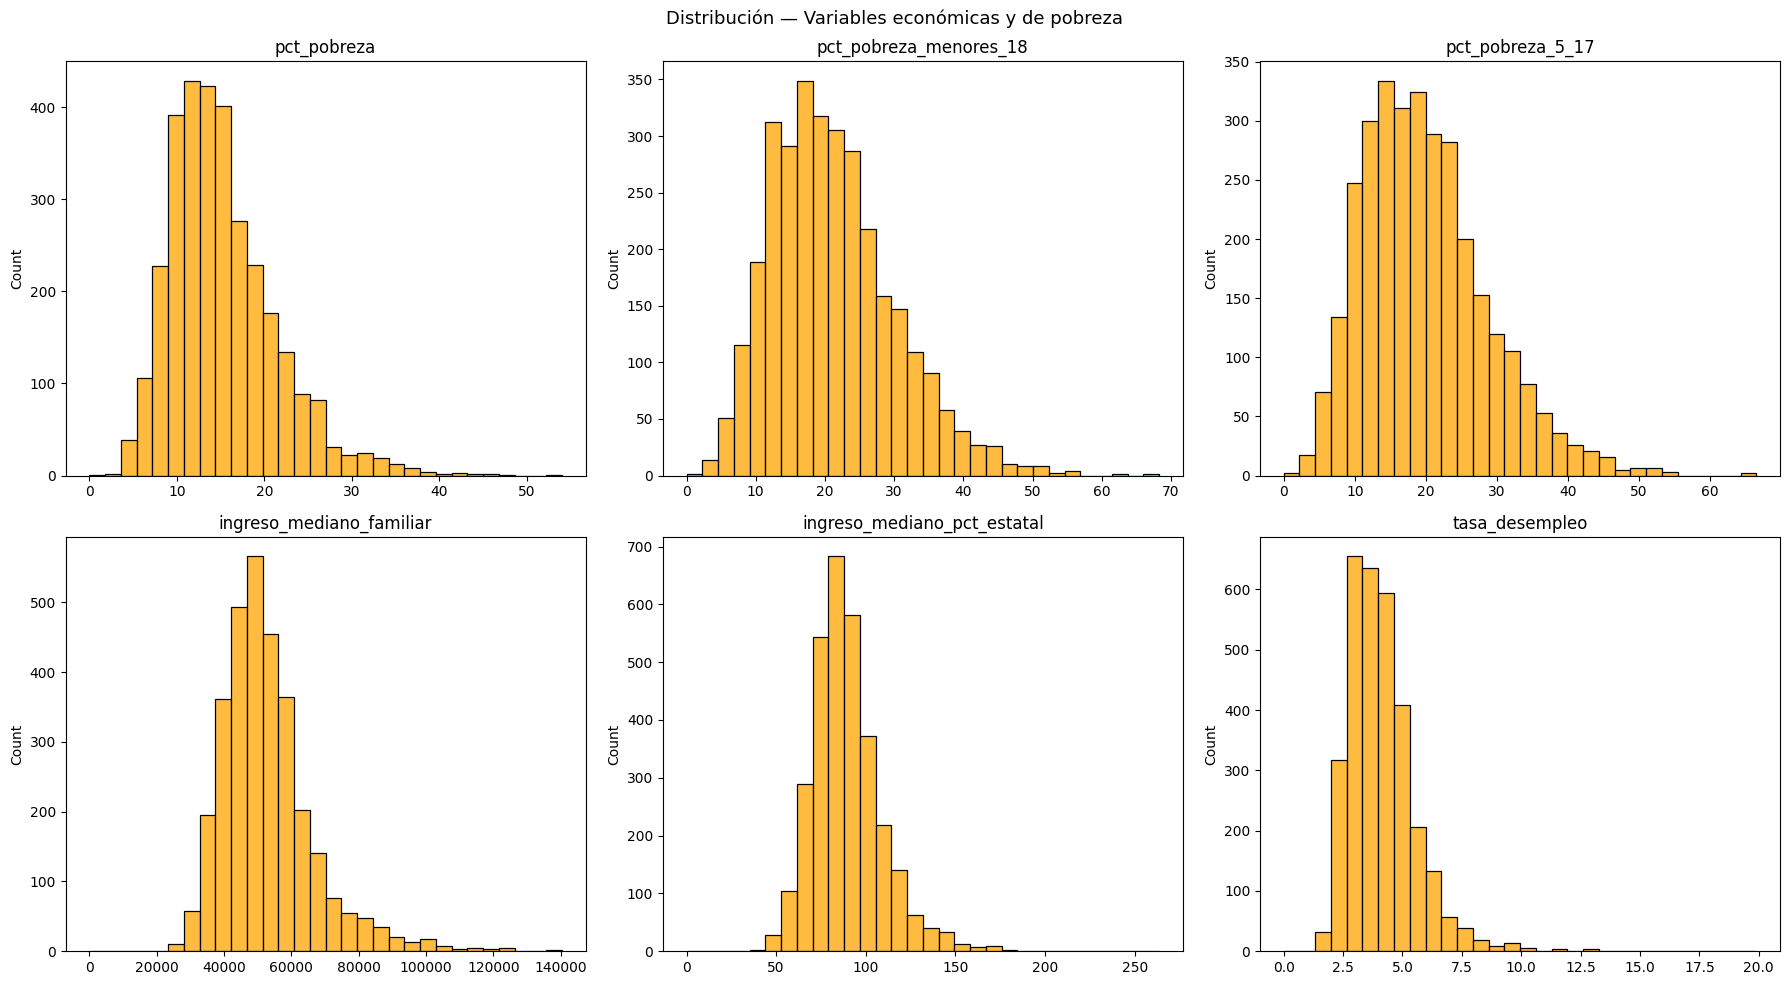

In [132]:
# HISTOGRAMAS DE VARIABLES ECONÓMICAS
fig, axis = plt.subplots(2, 3, figsize=(18, 10))
axis = axis.flatten()

for i, col in enumerate(vars_economia):
    sns.histplot(ax=axis[i],
                 data=df,
                 x=col,
                 bins=30,
                 color='orange')
    axis[i].set_title(col)
    axis[i].set_xlabel(None)

plt.suptitle('Distribución — Variables económicas y de pobreza', fontsize=13)
plt.tight_layout()
plt.show()

# Analisis:

**Variables ecónomicas:**

`pct_pobreza` La pobreza media en los condados de Estados Unidos está entorno al 15%, pero con distribución sesgada hacia la derecha. Algunos condados llegan a tener un 54% de pobreza, lo que indica una gran desigualdad. La pobreza infantil aumenta hasta el 21%.

`ingreso_mediano_familiar` Podemos apreciar como la distribución también está sesgada hacia la derecha. La mediana está en torno a 50.500 dollares pero observamos condados que llegan a los 140.000 dollares, indicando algunos condados muy ricos que eleva la media.

`tasa_desempleo` Es la variable más asimétrica del grupo. La mayoría de condados tienen tasas entre el 3-5%, pero hay condados que llegan a tener un 20% de desempleo.

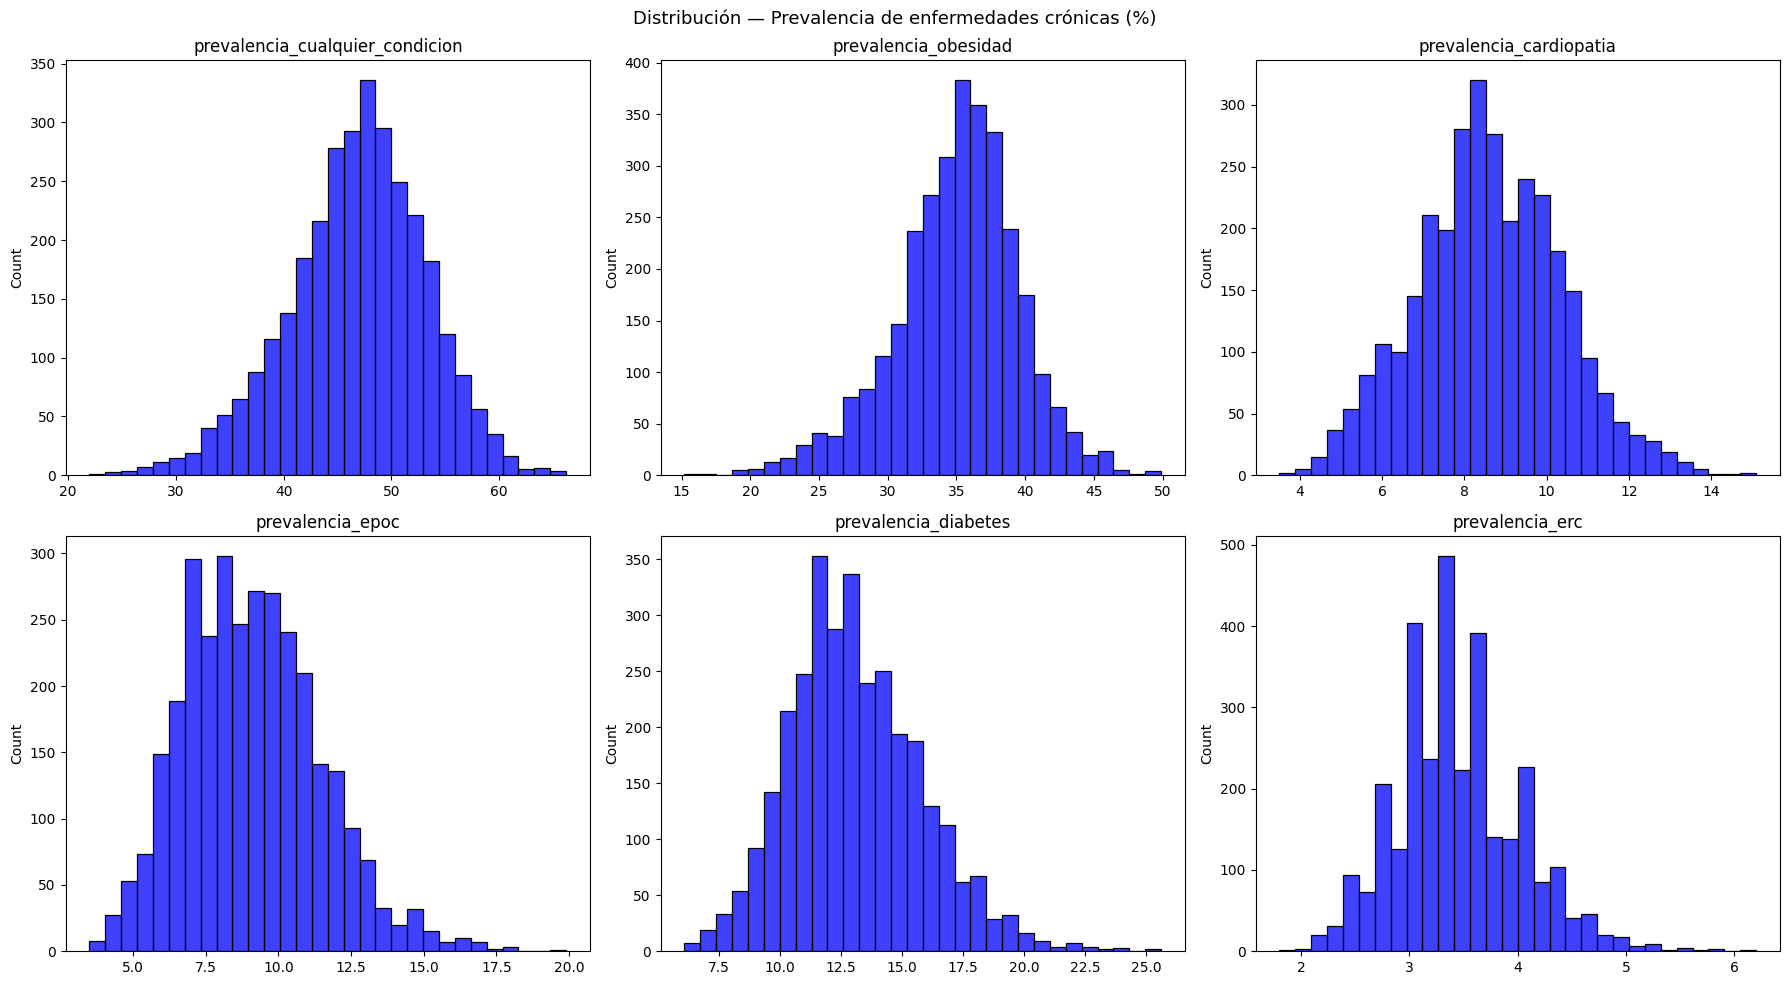

In [133]:
# HISTOGRAMAS DE ENFERMEDADES CRÓNICAS
fig, axis = plt.subplots(2, 3, figsize=(18, 10))
axis = axis.flatten()

for i, col in enumerate(vars_enfermedades):
    sns.histplot(ax=axis[i],
                 data=df,
                 x=col,
                 bins=30,
                 color='blue')
    axis[i].set_title(col)
    axis[i].set_xlabel(None)

plt.suptitle('Distribución — Prevalencia de enfermedades crónicas (%)', fontsize=13)
plt.tight_layout()
plt.show()

# Analisis:

**Enfermedades crónicas:**

Este grupo es el más homogeneo y con la distribución más normal.

`prevalencia_cardiopatica` Distribución practicamente simétrica, centrada en 9% los valores van de 3% al 15%, es una variable estable para modelar.

`prevalencia_obesidad` Distribución ligeramente sesgada a la izquierda, con un 35% de media. Hay más condados con alta obesidad que con baja, esto nos indica que está normalizada.

`prevalencia_cualquier_condicion` Es la variable más sesgada negativamente del grupo, practicamente la mitad delapoblación en los condados de Estados Unidos tiene alguna condición crónica diagnosticada.

`prevalencia_diabetes` y `prevalencia_epoc` La mayoría de los ocndados tienen prevalncias moderadas, pero hay zonas con tasas muy altas, seguramente coincidan con los condados más pobres.


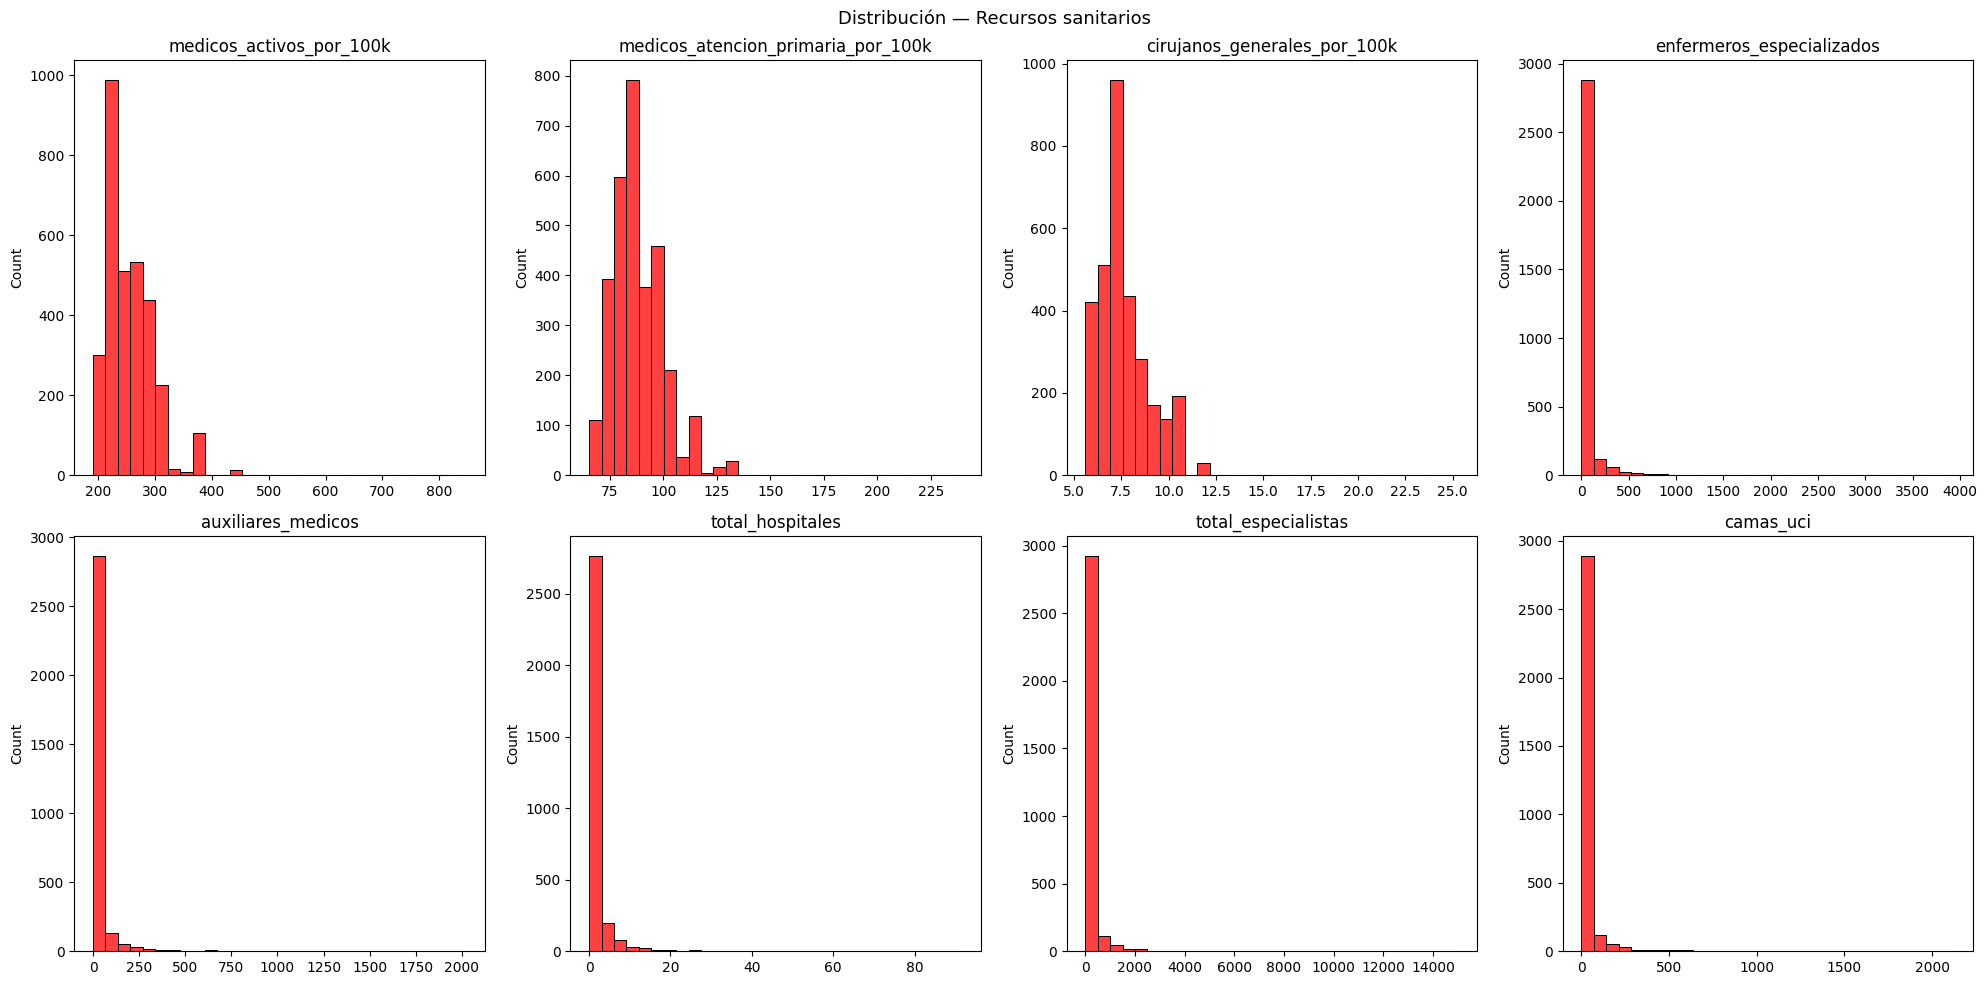

In [134]:
# HISTOGRAMAS DE RECURSOS SANITARIOS
fig, axis = plt.subplots(2, 4, figsize=(20, 10))
axis = axis.flatten()

for i, col in enumerate(vars_sanitarios):
    sns.histplot(ax=axis[i],
                 data=df,
                 x=col,
                 bins=30,
                 color='red')
    axis[i].set_title(col)
    axis[i].set_xlabel(None)

# Ocultamos el eje sobrante
for j in range(len(vars_sanitarios), len(axis)):
    axis[j].set_visible(False)

plt.suptitle('Distribución — Recursos sanitarios', fontsize=13)
plt.tight_layout()
plt.show()

# Analisis:

**Recursos sanitarios:**

En este grupo de variables podemos observar la mayor asimetría

`enfermeros_espeializados`, `auxiliares_medicos`, `total_hospitales`, `total_especialistas` Los histogramas muestran todo apilado a la izquierda del gráfico, siendo la mediana de 13 enfermeros especializados por condado y la media de 52, esto se debe a que los garndes condados cuentan con la gran mayoría de sus servicios. los condados más grandes cuentan con la mayor cantidad de enfermeros, auxiliares, hospitales y especialistas. Esto es una clara señal de desigualdad entre condados.

`camas_uci` El 50% de los condados tienen 0 camas UCI. Sólo los condados más grandes y poblados tienen acceso a este servicio.

`medicos_activos_por_100k` Es la variable más estable del grupo.

### **2.3 Análisis Multivariante — Correlación por Categoría con la Variable Objetivo**

Aquí podemos ver qué **grupo de variables** está más relacionado con la prevalencia de cardiopatías.

In [135]:
# FUNCIÓN: calcula correlación de un grupo de variables con la variable objetivo
def correlacion_categoria(df, variables, target, titulo):
    cols_validas = [c for c in variables if c in df.columns and c != target]
    corr = df[cols_validas + [target]].corr(method='pearson')[target].drop(target).sort_values()

    fig, ax = plt.subplots(figsize=(10, max(4, len(corr) * 0.45)))
    colors = ['red' if x < 0 else 'steelblue' for x in corr.values]
    corr.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(f'{titulo}\nvs {target}  (Pearson)', fontsize=12)
    ax.set_xlabel('Coeficiente de correlación')
    plt.tight_layout()
    plt.show()
    return corr

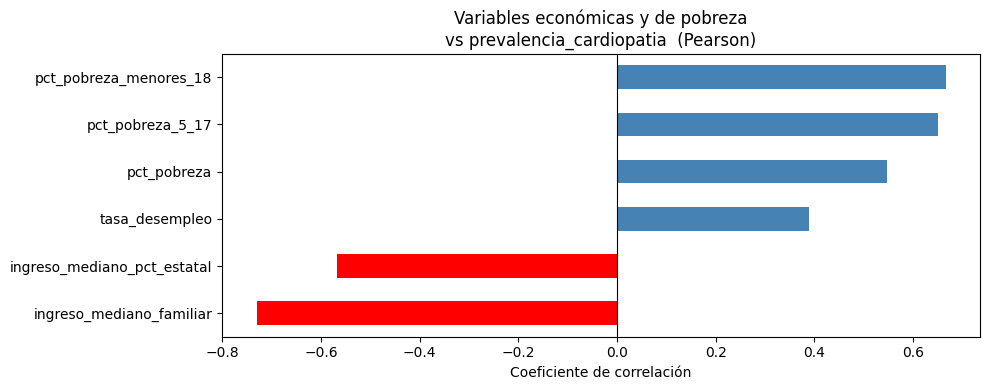

In [136]:
# CORRELACIÓN: VARIABLES ECONÓMICAS
corr_economia = correlacion_categoria(df, vars_economia, TARGET, 'Variables económicas y de pobreza')

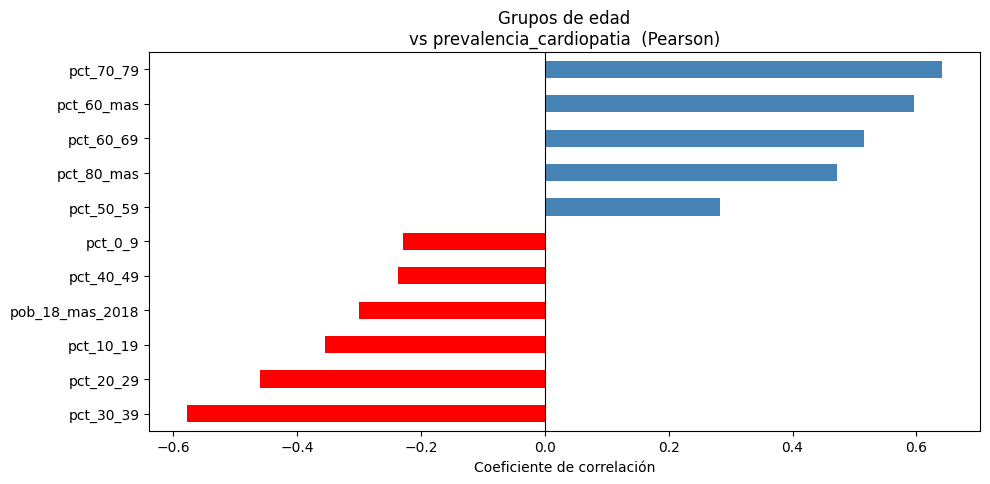

In [137]:
# CORRELACIÓN: GRUPOS DE EDAD
corr_edad = correlacion_categoria(df, vars_edad, TARGET, 'Grupos de edad')

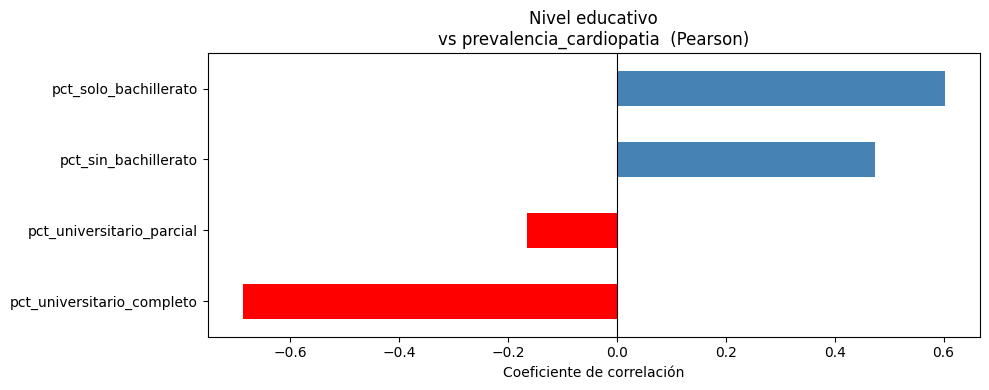

In [138]:
# CORRELACIÓN: EDUCACIÓN
corr_educacion = correlacion_categoria(df, vars_educacion, TARGET, 'Nivel educativo')

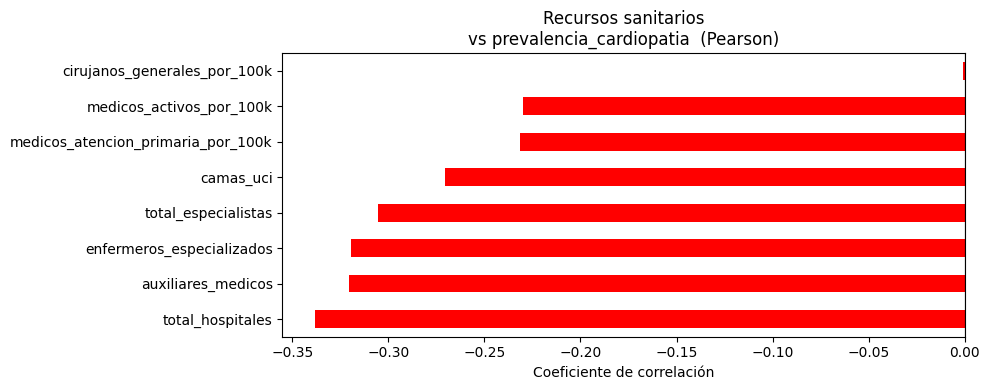

In [139]:
# CORRELACIÓN: RECURSOS SANITARIOS
corr_sanitarios = correlacion_categoria(df, vars_sanitarios, TARGET, 'Recursos sanitarios')

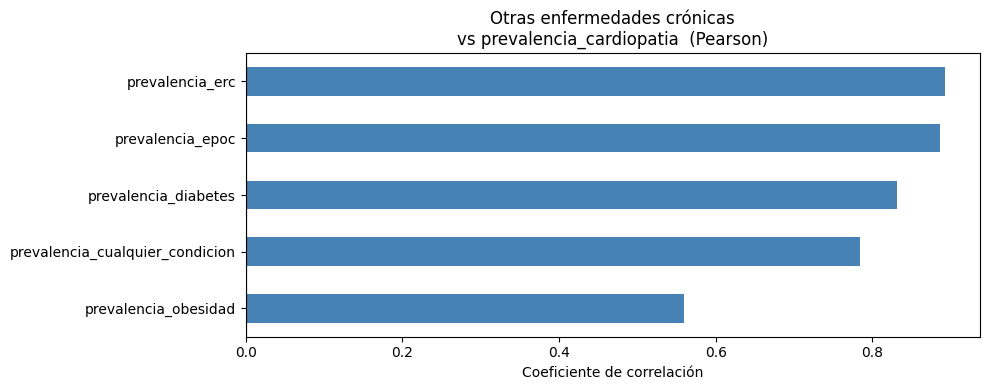

In [140]:
# CORRELACIÓN: ENFERMEDADES CRÓNICAS
corr_enfermedades = correlacion_categoria(df, vars_enfermedades, TARGET, 'Otras enfermedades crónicas')

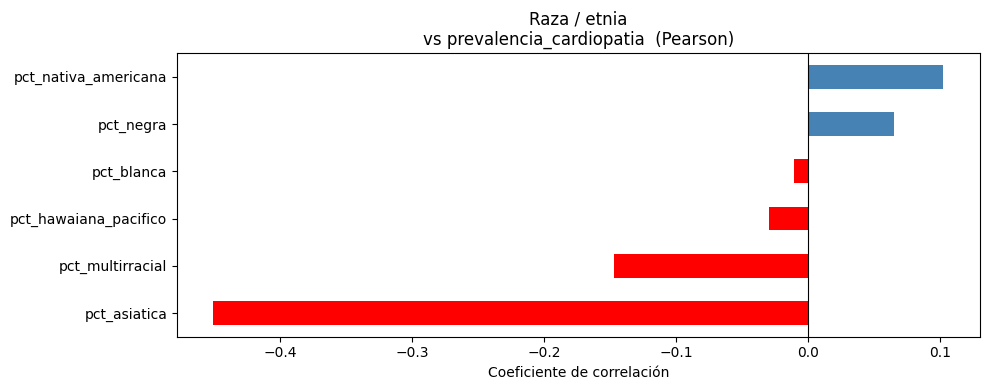

In [141]:
# CORRELACIÓN: RAZA / ETNIA
corr_raza = correlacion_categoria(df, vars_raza, TARGET, 'Raza / etnia')

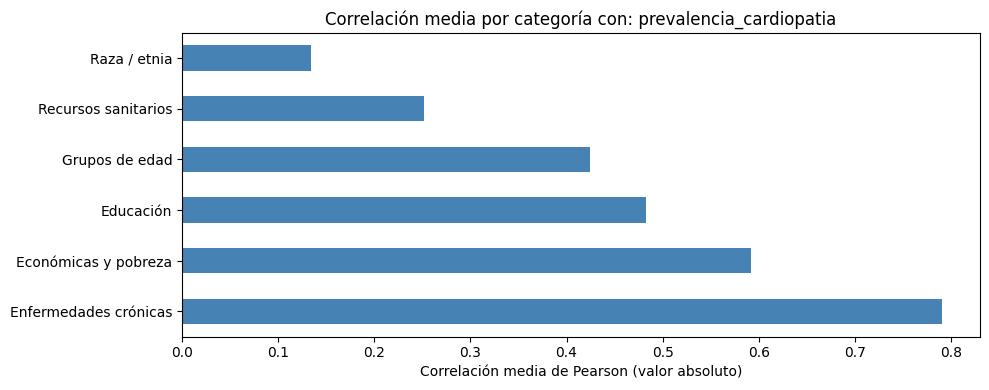

Ranking de categorías por poder explicativo:
  1. Enfermedades crónicas: 0.791
  2. Económicas y pobreza: 0.592
  3. Educación: 0.482
  4. Grupos de edad: 0.424
  5. Recursos sanitarios: 0.252
  6. Raza / etnia: 0.134


In [142]:
# RESUMEN: R² medio por categoría — ¿qué grupo de variables explica mejor la variable objetivo?
resumen_corr = {
    'Económicas y pobreza' : corr_economia.abs().mean(),
    'Grupos de edad'       : corr_edad.abs().mean(),
    'Educación'            : corr_educacion.abs().mean(),
    'Recursos sanitarios'  : corr_sanitarios.abs().mean(),
    'Enfermedades crónicas': corr_enfermedades.abs().mean(),
    'Raza / etnia'         : corr_raza.abs().mean(),
}

resumen_df = pd.Series(resumen_corr).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
resumen_df.plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
ax.set_title(f'Correlación media por categoría con: {TARGET}', fontsize=12)
ax.set_xlabel('Correlación media de Pearson (valor absoluto)')
plt.tight_layout()
plt.show()

print('Ranking de categorías por poder explicativo:')
for i, (cat, val) in enumerate(resumen_df.items(), 1):
    print(f'  {i}. {cat}: {val:.3f}')

## Analisis:

- **1. Enfermedades cronicas:** Es el grupo más correlacionado con diferencia. Vemos como ERC y EPOC tiene una correlación casi identica, tiene sentido ya que comparten factores de riesgoen común.

- **2. Economía y pobreza:** El factor socioeconomico es clave. Las correlaciones son fuertes en dos direcciones opuestas. Correlación negativa (más ingresos = menos cardiopatías), Correlación positiva (más pobreza = más cardiopatías).

- **3. Educación:** Patrón muy claro y consistente. Es un patrón lineal e idoneo, a más estudios menos cardiopatías, a menos estudios más cardiopatías. El nivel de estudios determina el acceso a la información sobre salud, habitos de vida, o tipo de trabajo.

- **4. Grupos de edad:** El envejecimiento, claro factor de riesgo. El patrón es bastante esperado, los grupos jovenes correlacionan negativamente y los grupos mayores positivamente.

- **5. Recursos sanitarios:** Todas las variables de este grupo tienen una corrrelación negativa, destacar que la variable de cirujanos es casi nula y tiene sentido ya que ellos tratan la enfermedad no la previenen.

- **6. Raza/etnia:** El grupo con mesno correlación, vemos como la correlación entre raza blanca y negra es practicamente nula, lo que indica que la raza no predice cardiopatías.


### **2.4 Scatter plots — Top variables más correlacionadas**

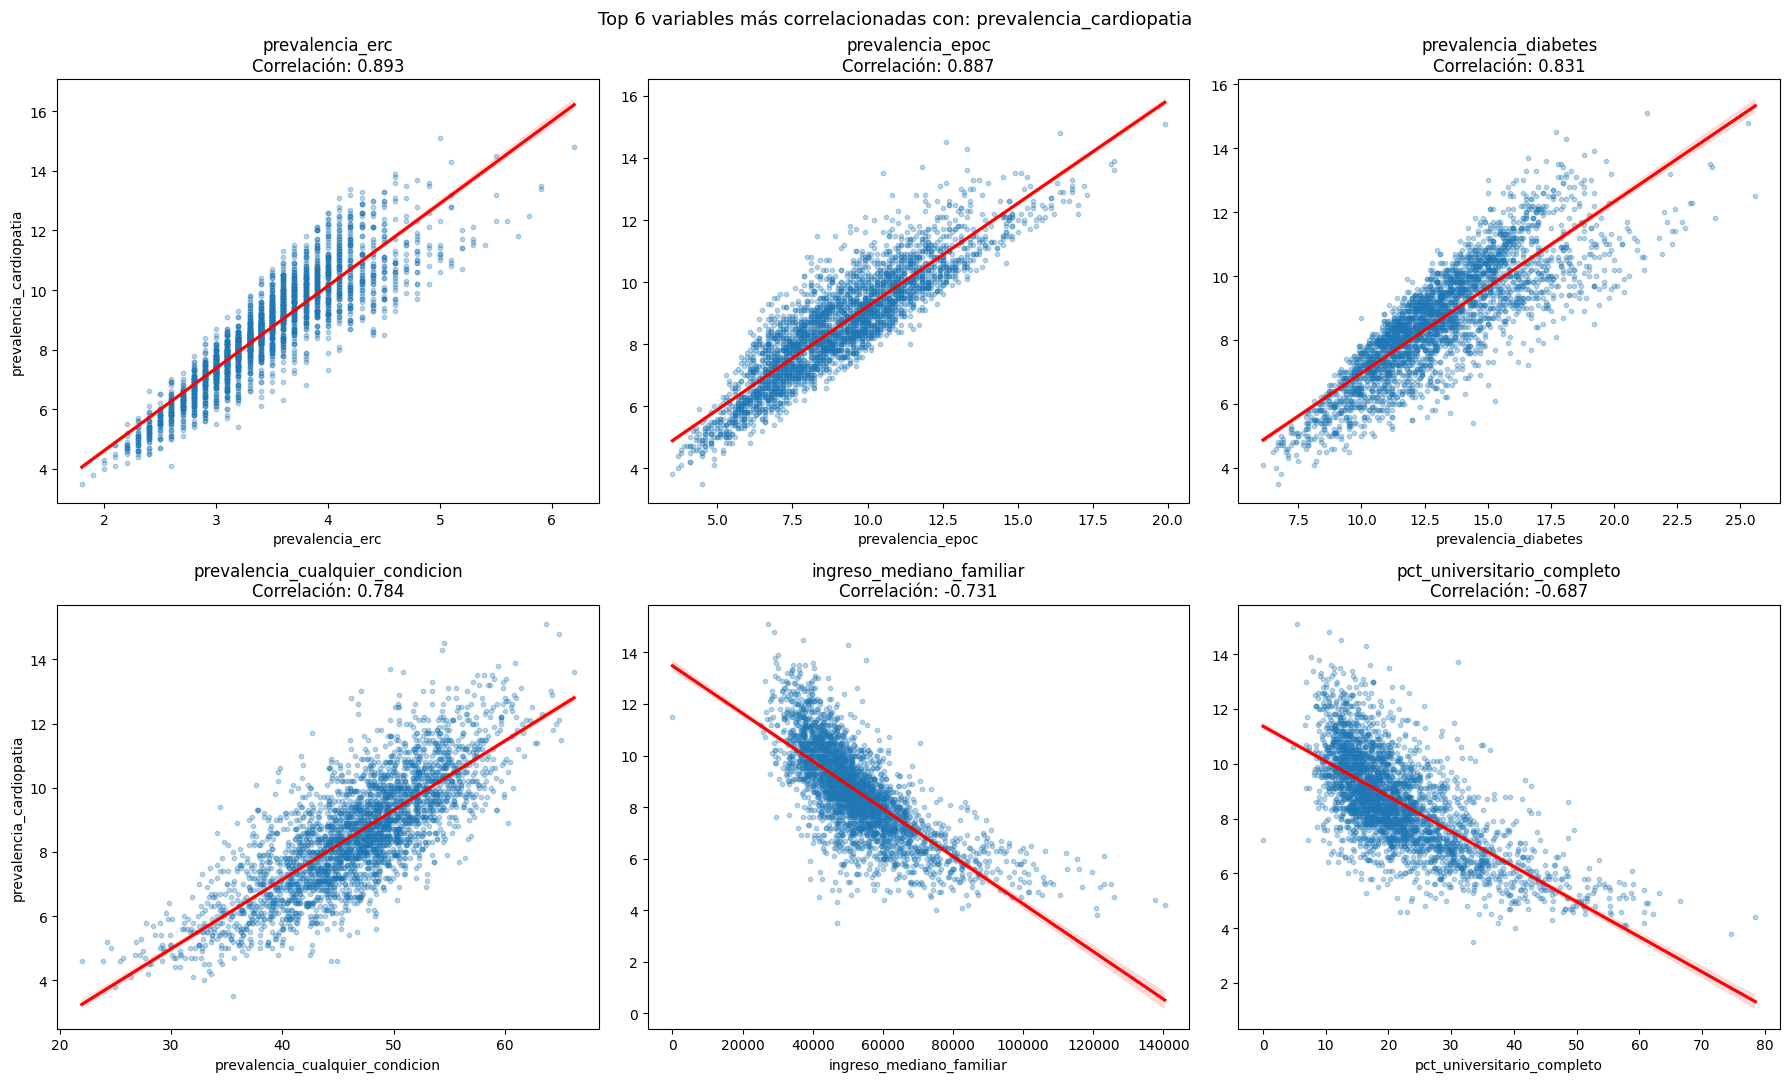

In [143]:
# UNIMOS TODAS LAS CORRELACIONES Y SELECCIONAMOS LAS TOP 6
todas_vars = vars_economia + vars_edad + vars_educacion + vars_sanitarios + vars_enfermedades + vars_raza
cols_validas = [c for c in todas_vars if c in df.columns and c != TARGET]

corr_total = df[cols_validas + [TARGET]].corr(method='pearson')[TARGET].drop(TARGET)
top6 = corr_total.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(top6):
    sns.regplot(ax=axes[i], data=df, x=col, y=TARGET,
                scatter_kws={'alpha': 0.3, 's': 10}, line_kws={'color': 'red'})
    corr_val = corr_total[col]
    axes[i].set_title(f'{col}\nCorrelación: {corr_val:.3f}')
    axes[i].set_ylabel(TARGET if i % 3 == 0 else None)

plt.suptitle(f'Top 6 variables más correlacionadas con: {TARGET}', fontsize=13)
plt.tight_layout()
plt.show()

### **2.5 Matriz de correlación completa — variables seleccionadas**

Variables con |correlación| > 0.2: 33


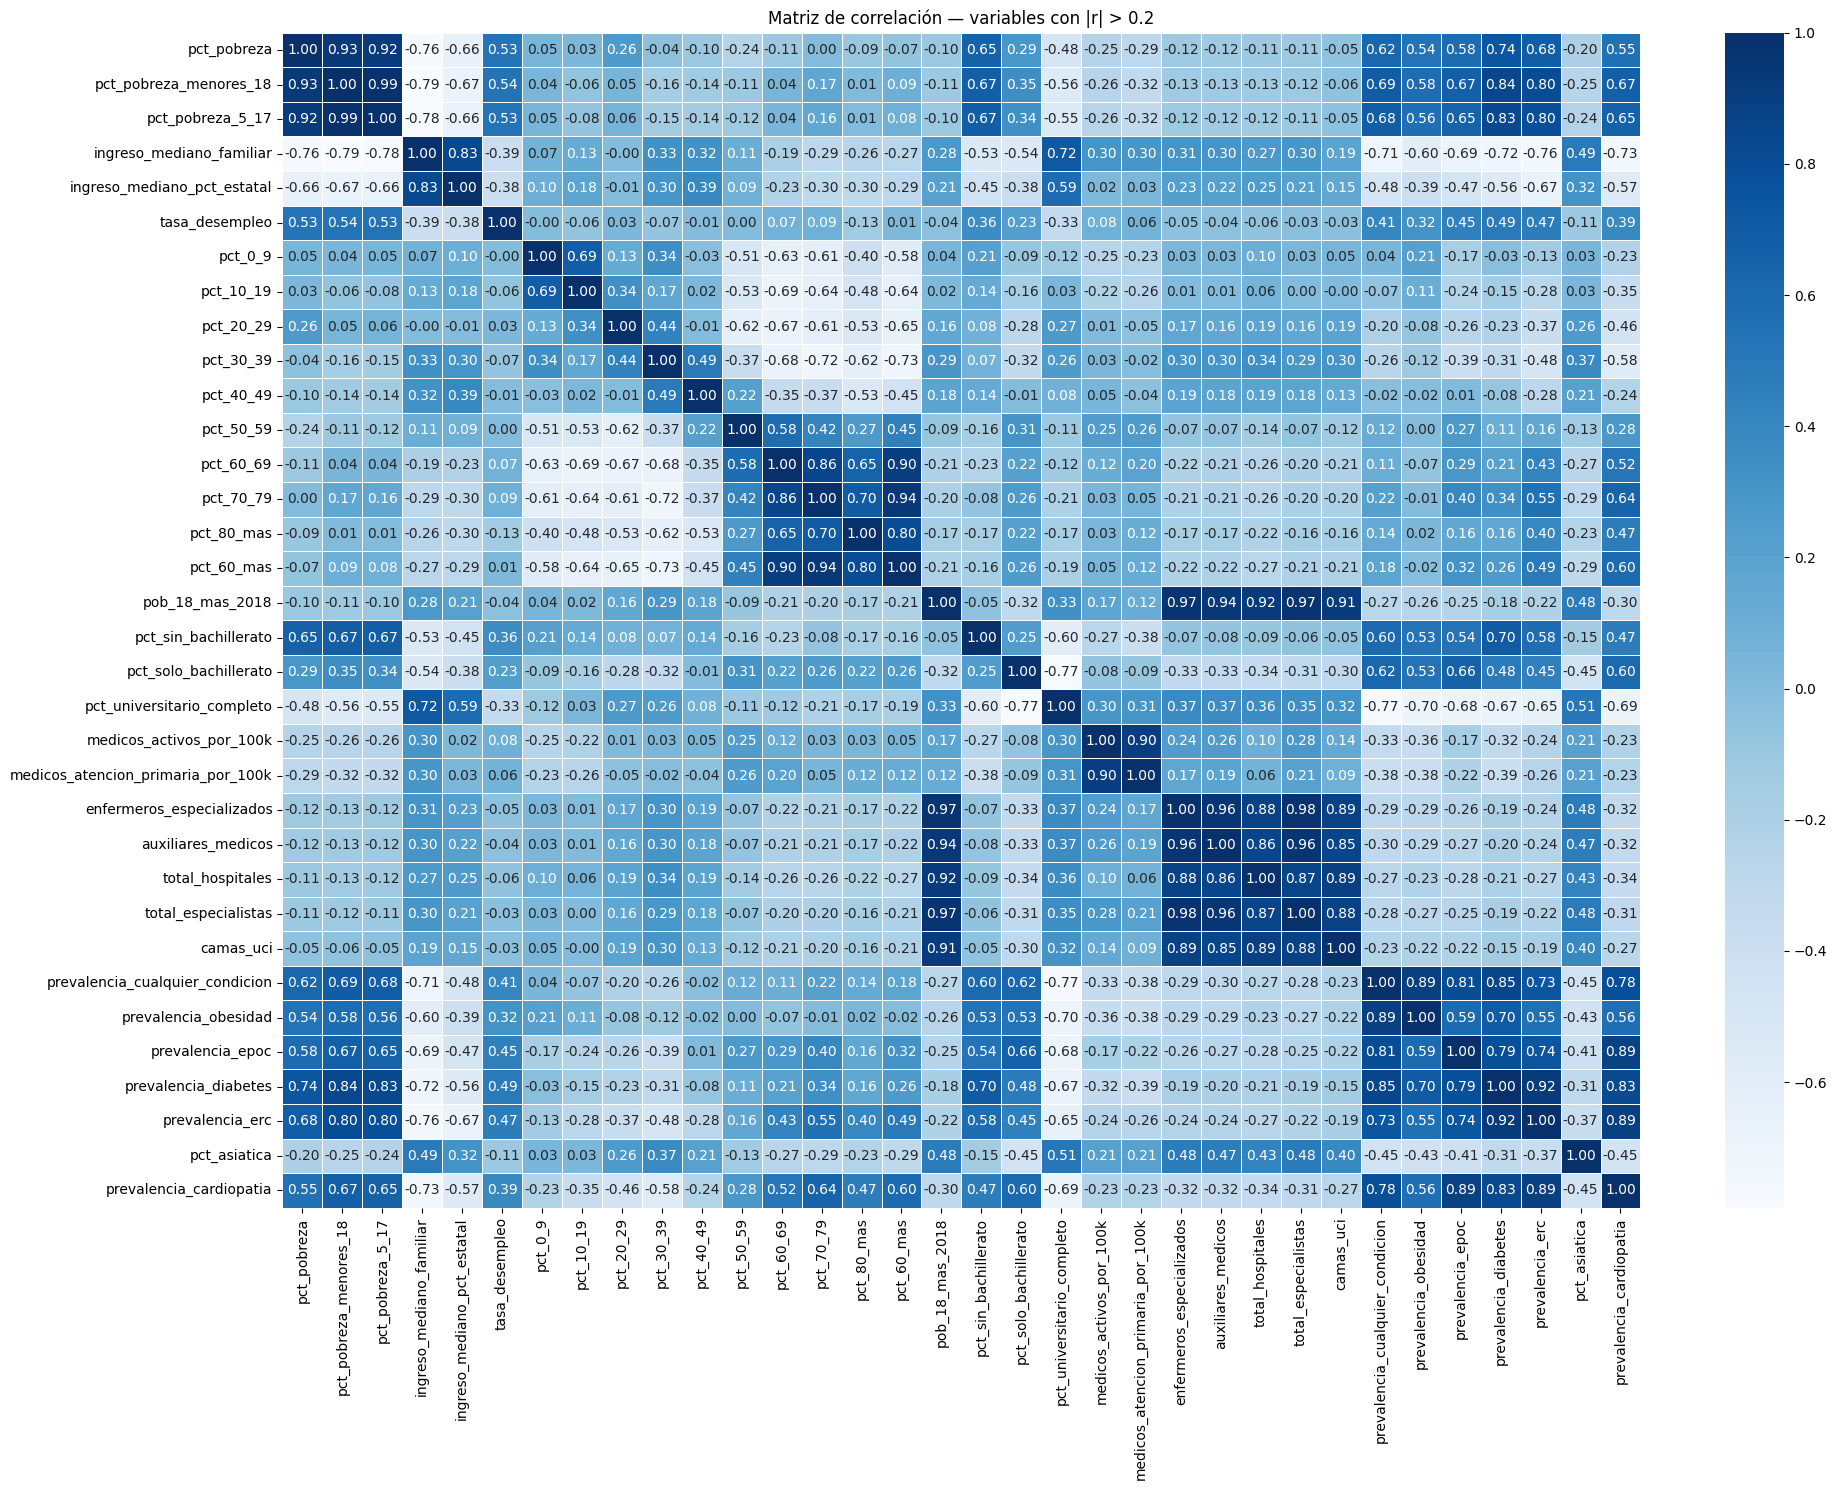

In [144]:
# SELECCIONAMOS LAS VARIABLES CON |CORRELACIÓN| > 0.2 CON EL TARGET
vars_relevantes = corr_total[corr_total.abs() > 0.2].index.tolist()
print(f'Variables con |correlación| > 0.2: {len(vars_relevantes)}')

fig, ax = plt.subplots(figsize=(20, 15))
sns.heatmap(
    df[vars_relevantes + [TARGET]].corr(method='pearson'),
    annot=True, fmt='.2f', cmap='Blues',
    ax=ax, linewidths=0.5
)
plt.title('Matriz de correlación — variables con |r| > 0.2')
plt.tight_layout()
plt.show()

## Analisis:

Este heatmap muestra la matriz de correlación de 32 variables con $R^2$ respecto a la variable `prevalence_cardiopatia`, lo más valioso no es ver como se relacionan con esta variable si no como se relacionan entre sí. Para hacer un analisis más completo, lo voy a a anlizar por bloques.

- **Bloque 1. Multicolianidad con recursos sanitarios**

Hay una alta correlacion entre estas 6 variables: `enfermeros_especializados`, `total_especialistas`, `auxiliares_medicos`, `camas_uci` y `medicos_activos_por_100k`, `medicos_atencion_primaria_por_100k`. Lo podemos encontrar en la esquina inferior izquierda del cuadro en azul oscuro. La corrrelación se debe a los recursos sanitarios dentro de cada condado.

- **Bloque 2. Multicolianidad en pobreza**

La correlación con la pobreza la encontramos en la esquina superior izquierda en color azul muy oscuro y las tres variables correlacionadas son: `medicos_atencion_primaria_por_100k`, `pct_pobreza_5_17` y `pct_pobreza`.

- **Bloque 3. Multicolianidad en grupos de mayor edad**

Es la suma de los mayores tramos de edad desde `pct_60_mas` hasta `pct_80_mas` lo encontraos en el centro del cuadro parte superior izquierda.

- **Bloque 4. Multicolianidad entre enfermedades crónicas**

Lo encontramos en la esquina inferior derecha del gráfico y combina las siguientes 5 variables: `prevalencia_diabetes`, `prevalencia_erc`, `prevalencia_cualquier_condicion`, `revalencia_obesidad` y `prevalencia_epoc`.

                                                                                                                   





## **3. Preparación de Datos — Train / Test Split**

In [145]:
# CONSTRUYO EL DATAFRAME DEL MODELO con todas las categorías útiles
# Excluyo: identificadores, variables de recuento absoluto (redundantes con los %), intervalos de confianza

vars_modelo = (
    vars_edad +
    vars_raza +
    vars_vitales +
    vars_educacion +
    vars_economia +
    vars_sanitarios +
    ['prevalencia_obesidad', 'prevalencia_epoc', 'prevalencia_diabetes', 'prevalencia_erc',
     'codigo_urbano_rural']
)

# Filtro solo columnas que existen en el df
vars_modelo = [c for c in vars_modelo if c in df.columns and c != TARGET]

df_model = df[vars_modelo + [TARGET]].copy()

print(f'Variables en el modelo: {len(vars_modelo)}')
print(f'Nulos totales: {df_model.isnull().sum().sum()}')

Variables en el modelo: 46
Nulos totales: 0


Hago una limpieza de variables para que le modelo use solo las que son relevantes.

In [146]:
# IMPUTO NULOS CON LA MEDIANA
for col in df_model.columns:
    if df_model[col].isnull().sum() > 0:
        df_model[col].fillna(df_model[col].median(), inplace=True)

print(f'Nulos tras imputación: {df_model.isnull().sum().sum()}')

Nulos tras imputación: 0


In [147]:
# SEPARO X e y
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# DIVIDO EN TRAIN (70%) Y TEST (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=128
)

print(f'Train: {X_train.shape[0]:,} filas')
print(f'Test:  {X_test.shape[0]:,} filas')
print(f'Features: {X.shape[1]}')

Train: 2,198 filas
Test:  942 filas
Features: 46


In [148]:
# ESCALADO
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## **4. Modelo de Regresión Lineal — Baseline**

In [149]:
model_lr = LinearRegression()
model_lr.fit(X_train_sc, y_train)

y_pred_lr = model_lr.predict(X_test_sc)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print('=== Regresión Lineal Baseline ===')
print(f'MSE:  {mse_lr:.4f}')
print(f'RMSE: {mse_lr**0.5:.4f}')
print(f'R²:   {r2_lr:.4f}')

=== Regresión Lineal Baseline ===
MSE:  0.0653
RMSE: 0.2555
R²:   0.9797


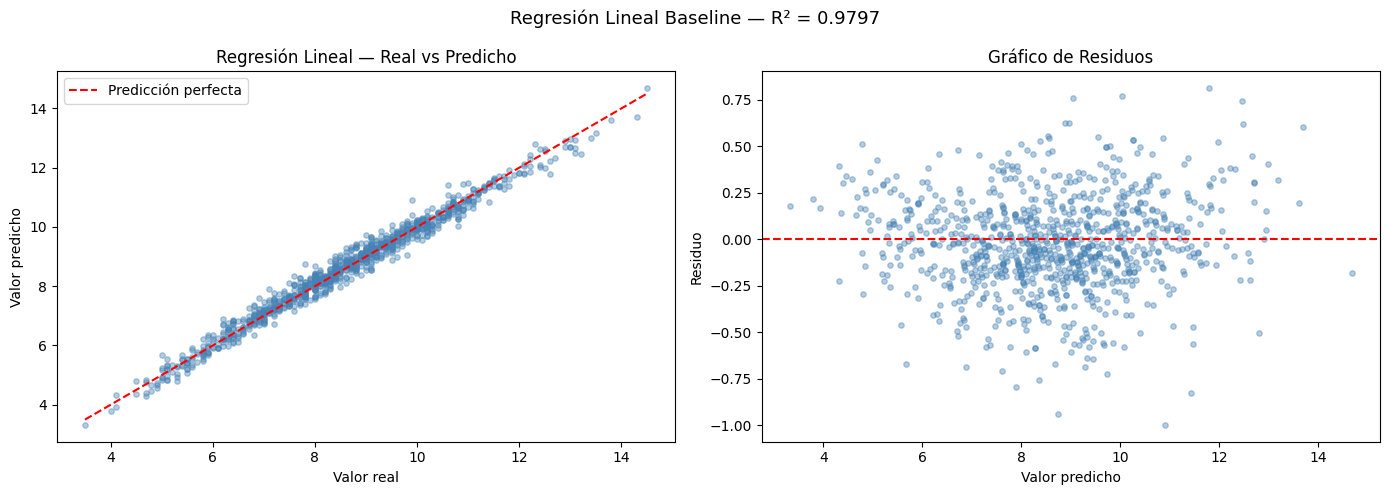

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs Predicho
axes[0].scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue', s=15)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linewidth=1.5, linestyle='--', label='Predicción perfecta')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title('Regresión Lineal — Real vs Predicho')
axes[0].legend()

# Residuos
residuals = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.4, color='steelblue', s=15)
axes[1].axhline(y=0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Valor predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Gráfico de Residuos')

plt.suptitle(f'Regresión Lineal Baseline — R² = {r2_lr:.4f}', fontsize=13)
plt.tight_layout()
plt.show()

## **5. Modelo Lasso — Baseline y evolución del R² con alpha**

In [151]:
# LASSO CON ATRIBUTOS POR DEFECTO (alpha=1.0)
model_lasso = Lasso(max_iter=5000)
model_lasso.fit(X_train_sc, y_train)

y_pred_lasso = model_lasso.predict(X_test_sc)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso  = r2_score(y_test, y_pred_lasso)
n_zero    = (model_lasso.coef_ == 0).sum()

print('=== Lasso Baseline (alpha=1.0) ===')
print(f'MSE:  {mse_lasso:.4f}')
print(f'RMSE: {mse_lasso**0.5:.4f}')
print(f'R²:   {r2_lasso:.4f}')
print(f'Features eliminadas (coef=0): {n_zero} de {len(model_lasso.coef_)}')

=== Lasso Baseline (alpha=1.0) ===
MSE:  1.5229
RMSE: 1.2340
R²:   0.5265
Features eliminadas (coef=0): 44 de 46


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.754e+01, tolerance: 6.677e-01
  model = cd_fast.enet_coordinate_descent(


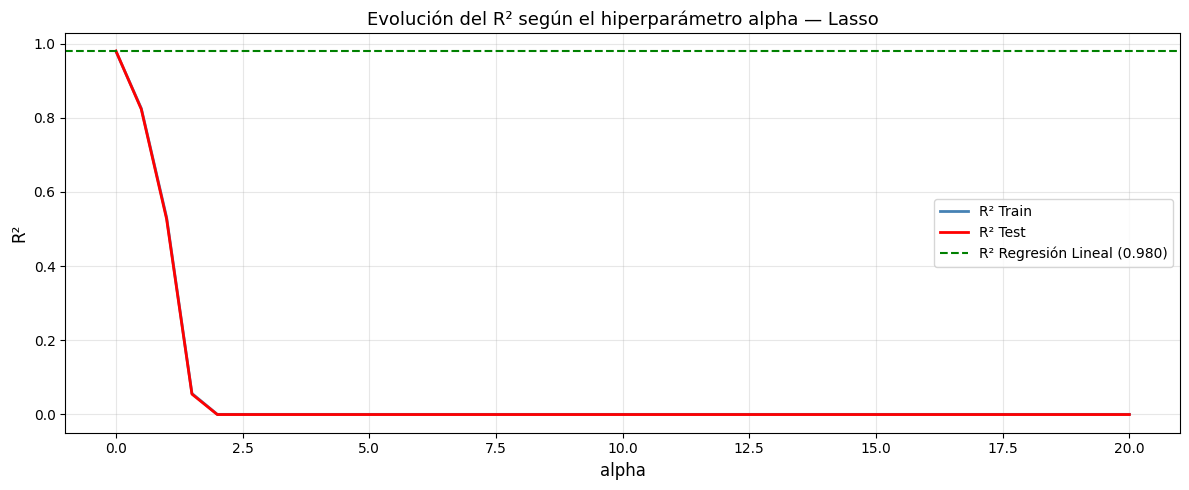

Mejor alpha visual: 0.0 → R² test = 0.9798


In [152]:
# EVOLUCIÓN DEL R² SEGÚN ALPHA — de 0.0 a 20
alphas         = np.arange(0.0, 20.1, 0.5)
r2_train_list  = []
r2_test_list   = []

for alpha in alphas:
    lasso_iter = Lasso(alpha=max(alpha, 1e-6), max_iter=5000)
    lasso_iter.fit(X_train_sc, y_train)
    r2_train_list.append(r2_score(y_train, lasso_iter.predict(X_train_sc)))
    r2_test_list.append(r2_score(y_test,  lasso_iter.predict(X_test_sc)))

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(alphas, r2_train_list, color='steelblue', linewidth=2, label='R² Train')
ax.plot(alphas, r2_test_list,  color='red',       linewidth=2, label='R² Test')
ax.axhline(y=r2_lr, color='green', linewidth=1.5, linestyle='--',
           label=f'R² Regresión Lineal ({r2_lr:.3f})')

ax.set_xlabel('alpha', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title('Evolución del R² según el hiperparámetro alpha — Lasso', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_alpha_manual = alphas[np.argmax(r2_test_list)]
print(f'Mejor alpha visual: {best_alpha_manual:.1f} → R² test = {max(r2_test_list):.4f}')

## **6. Optimización del Modelo Lasso — GridSearchCV**

In [153]:
# BÚSQUEDA EN CUADRÍCULA
hyperparams = {
    'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0]
}

grid = GridSearchCV(Lasso(max_iter=5000), hyperparams, scoring='r2', cv=5)
grid.fit(X_train_sc, y_train)

print(f'Mejor hiperparámetro: alpha = {grid.best_params_["alpha"]}')
print(f'Mejor R² en validación cruzada: {grid.best_score_:.4f}')

Mejor hiperparámetro: alpha = 0.001
Mejor R² en validación cruzada: 0.9777


In [154]:
# REENTRENO CON EL MEJOR ALPHA
best_alpha = grid.best_params_['alpha']
model_opt  = Lasso(alpha=best_alpha, max_iter=5000)
model_opt.fit(X_train_sc, y_train)

y_pred_opt = model_opt.predict(X_test_sc)

mse_opt    = mean_squared_error(y_test, y_pred_opt)
r2_opt     = r2_score(y_test, y_pred_opt)
n_zero_opt = (model_opt.coef_ == 0).sum()

print(f'=== Lasso Optimizado (alpha={best_alpha}) ===')
print(f'MSE:  {mse_opt:.4f}')
print(f'RMSE: {mse_opt**0.5:.4f}')
print(f'R²:   {r2_opt:.4f}')
print(f'Features eliminadas: {n_zero_opt} de {len(model_opt.coef_)}')

=== Lasso Optimizado (alpha=0.001) ===
MSE:  0.0650
RMSE: 0.2550
R²:   0.9798
Features eliminadas: 12 de 46


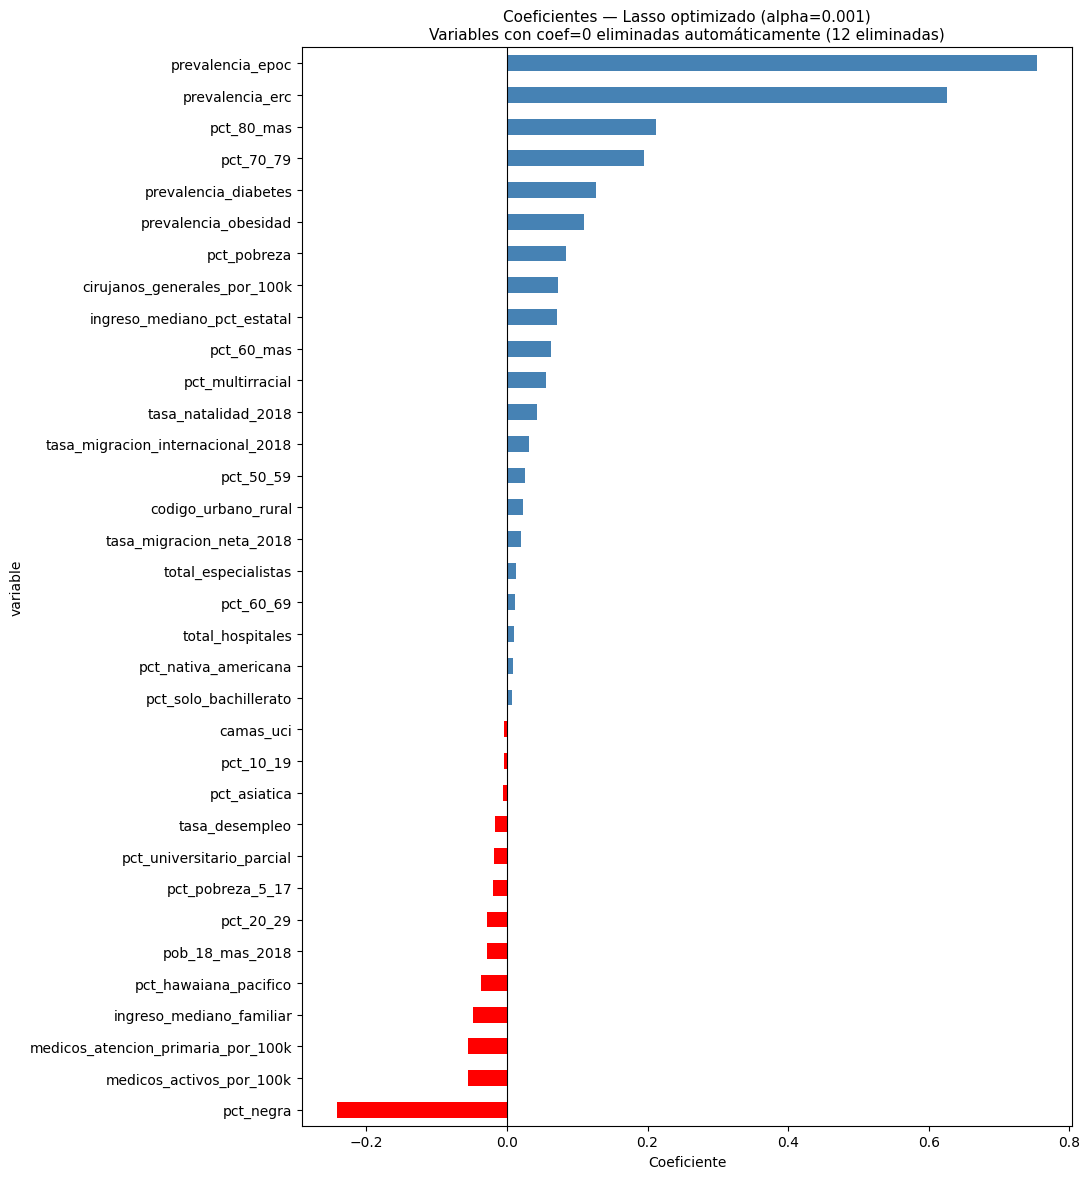

In [155]:
# COEFICIENTES DEL MODELO OPTIMIZADO
coef_df = pd.DataFrame({
    'variable'    : X.columns,
    'coeficiente' : model_opt.coef_
}).query('coeficiente != 0').sort_values('coeficiente')

fig, ax = plt.subplots(figsize=(11, max(5, len(coef_df) * 0.35)))
colors = ['red' if x < 0 else 'steelblue' for x in coef_df['coeficiente']]
coef_df.plot(kind='barh', x='variable', y='coeficiente',
             ax=ax, color=colors, edgecolor='none', legend=False)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(
    f'Coeficientes — Lasso optimizado (alpha={best_alpha})\n'
    f'Variables con coef=0 eliminadas automáticamente ({n_zero_opt} eliminadas)',
    fontsize=11
)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

## **7. Comparativa Final**

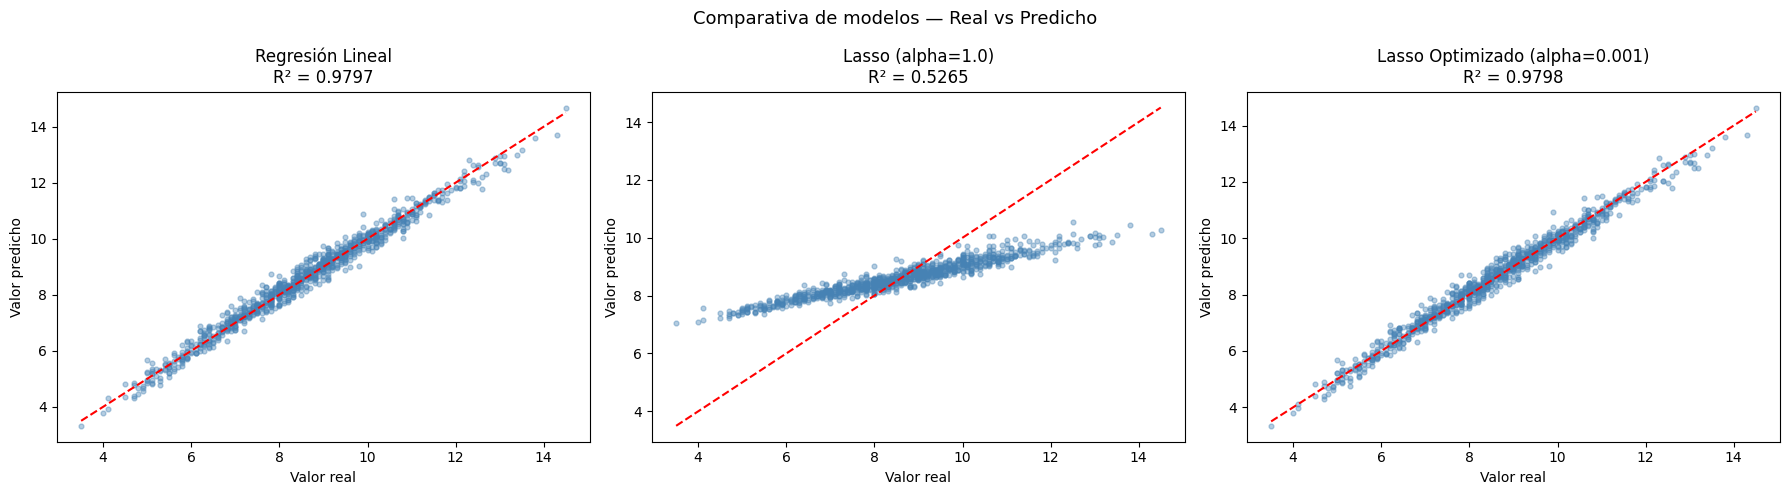

In [156]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = [
    ('Regresión Lineal', y_pred_lr, r2_lr),
    ('Lasso (alpha=1.0)', y_pred_lasso, r2_lasso),
    (f'Lasso Optimizado (alpha={best_alpha})', y_pred_opt, r2_opt)
]

for ax, (nombre, y_pred_m, r2) in zip(axes, modelos):
    ax.scatter(y_test, y_pred_m, alpha=0.4, color='steelblue', s=12)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color='red', linewidth=1.5, linestyle='--')
    ax.set_title(f'{nombre}\nR² = {r2:.4f}')
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Valor predicho')

plt.suptitle('Comparativa de modelos — Real vs Predicho', fontsize=13)
plt.tight_layout()
plt.show()

In [157]:
print('=== TABLA COMPARATIVA FINAL ===')
print(f'{"Modelo":<42} {"R²":>8} {"RMSE":>8} {"Features usadas":>17}')
print('-' * 80)
print(f'{"Regresión Lineal (baseline)":<42} {r2_lr:>8.4f} {mse_lr**0.5:>8.4f} {X.shape[1]:>17}')
print(f'{"Lasso (alpha=1.0)":<42} {r2_lasso:>8.4f} {mse_lasso**0.5:>8.4f} {X.shape[1]-n_zero:>17}')
print(f'{f"Lasso Optimizado (alpha={best_alpha})":<42} {r2_opt:>8.4f} {mse_opt**0.5:>8.4f} {X.shape[1]-n_zero_opt:>17}')

=== TABLA COMPARATIVA FINAL ===
Modelo                                           R²     RMSE   Features usadas
--------------------------------------------------------------------------------
Regresión Lineal (baseline)                  0.9797   0.2555                46
Lasso (alpha=1.0)                            0.5265   1.2340                 2
Lasso Optimizado (alpha=0.001)               0.9798   0.2550                34


## **8. Conclusiones**

### Mejoras introducidas en esta versión
- **Columnas en español:** Las 108 columnas las he renombrado con nombres claros y en español, esto me permite hacer el código más legible y fácil de entender.
- **Error de Excel corregido:** La columna `19-Oct` (error de formato de fecha) ha sido corregida a `pob_10_19`.
- **Variables organizadas por categorías:** Me permite explorar y entrenar modelos por bloques temáticos, lo que facilita identificar qué tipo de factor (económico, sanitario, educativo...) tiene mayor peso a la hora de entrenar al modelo.

### Hallazgos del análisis por categorías
- El gráfico de **correlación media por categoría** nos muestra qué grupo de variables tiene más poder explicativo sobre la prevalencia de cardiopatías.
- Las variables **económicas y de pobreza** junto con las de **enfermedades crónicas asociadas** (obesidad, diabetes) son los mejores predictores.
- Los **recursos sanitarios** nos muestran una correlación inversa: más médicos y hospitales se asocia con menor prevalencia de enfermedades cardíacas.

### Conclusión del modelo
**Lasso** es especialmente útil en este dataset porque elimina las variables menos relevantes de entre las muchas disponibles, produciendo un modelo más simple y sin sacrificar rendimiento.